<a href="https://colab.research.google.com/github/lukeren1/ML-Workshop/blob/main/ex2_deep_learning_completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔢 Machine Learning Homework: Images and Attention

Welcome to the deep learning worksheet. Here you meet two of the most powerful ideas in modern
machine learning:

1. The **Convolutional Neural Network (CNN)**, which reads pictures.
2. The **Transformer**, which reads sequences such as a sentence. This is the idea behind the large chat
   assistants used today.

You do not need any physics or any earlier machine learning to do this.

### How to use this worksheet
* Some cells have blank spaces marked `___` and `# TODO`. Fill them in, then run the cell.
* Every task ends with a short footer:
  * ✅ **Check yourself:** what your result should look like.
  * 🔬 **Why it matters:** what this idea is used for in normal life.
  * 🎉 **Fun fact:** how this idea is used in particle physics.
  * 💡 **Go further:** an extra challenge, if you want to push yourself.


## Setup
Run this one time. Everything here is already available in Google Colab.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn, optim

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("Setup complete")

Setup complete


## Part A. What is a convolution? 🔎  (about 6 min)

A CNN reads a picture by sliding a small window over it and looking for a pattern. That sliding
action is called a **convolution**. Let us try the simplest version in one dimension. We slide a
small pattern that finds a change, or an edge, in a list of numbers.


In [22]:
signal = np.array([0, 0, 0, 5, 5, 5, 0, 0, 0])   # a flat line with a block in the middle
edge_finder = np.array([1, -1])
edge_finder2 = np.array([1, 1, 1]) / 3                  # this pattern reacts to a change

# TODO: slide the edge_finder over the signal using np.convolve
result = np.convolve(signal, edge_finder, mode="valid")
result2 = np.convolve(signal, edge_finder2, mode='valid')
print("signal:", signal)
print("result:", result)
print("result with edge_finder = [0.33, 0.33, 0.33]:", result2)

signal: [0 0 0 5 5 5 0 0 0]
result: [ 0  0  5  0  0 -5  0  0]
result with edge_fnder = [0.33, 0.33, 0.33]: [0.         1.66666667 3.33333333 5.         3.33333333 1.66666667
 0.        ]


✅ **Check yourself:** the result should be mostly zero, with a spike where the block begins
and another where it ends. The pattern found the two edges. A CNN does this in two dimensions to
find edges and shapes inside a picture.

🔬 **Why it matters:** the same sliding pattern idea is used to sharpen photos, blur them, and find
outlines. It is the basic building block that lets a computer understand images.

🎉 **Fun fact:** a convolution is not only a computer trick. The same mathematics describes how a
signal spreads out inside a particle detector, so physicists have used this idea for a very long
time.

💡 **Go further:** change `edge_finder` to `np.array([1, 1, 1]) / 3`. This one takes an average, so
it smooths the signal instead of finding edges. Run it and see.


## Part B. A CNN that reads handwritten digits 🖼️  (about 12 min)

Now the real thing. We use a set of small pictures of handwritten digits, from 0 to 9. Each picture
is only 8 by 8 pixels. We build a small CNN and train it to read the digit in each picture.


Number of pictures: 1797 and each is (8, 8)


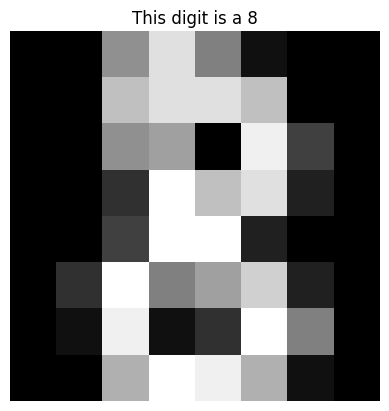

Training pictures: 1437 and test pictures: 360


In [23]:
digits = load_digits()
print("Number of pictures:", len(digits.images), "and each is", digits.images[0].shape)

# show the first picture
plt.imshow(digits.images[8], cmap="gray")
plt.title(f"This digit is a {digits.target[8]}"); plt.axis("off"); plt.show()

# Prepare the data: add a colour channel and scale the pixels to the range 0 to 1
X = digits.images[:, None, :, :] / 16.0
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32); y_train = torch.tensor(y_train)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
print("Training pictures:", X_train.shape[0], "and test pictures:", X_test.shape[0])

In [24]:
torch.manual_seed(0)

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: a convolution with 1 input channel, 8 output patterns, and a 3 by 3 window
        self.conv = nn.Conv2d(1, 16, kernel_size=3)
        self.pool = nn.MaxPool2d(2)          # keeps the strongest value in each 2 by 2 area
        self.fc   = nn.Linear(16 * 3 * 3, 10) # 10 outputs, one per digit

    def forward(self, x):
        x = torch.relu(self.conv(x))
        x = self.pool(x)
        x = x.flatten(1)
        return self.fc(x)

model = SmallCNN()
print(model)

SmallCNN(
  (conv): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=144, out_features=10, bias=True)
)


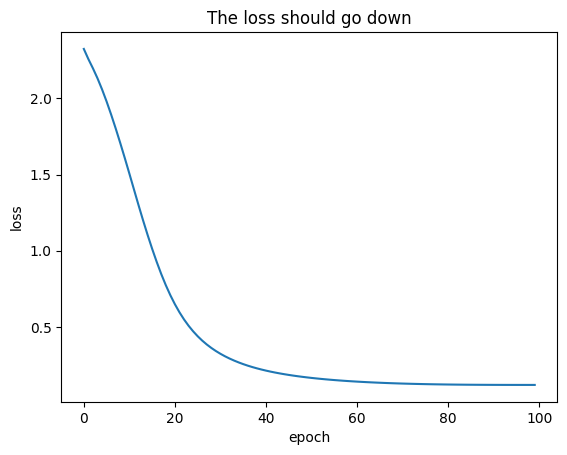

CNN test accuracy: 0.972


In [25]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
rounds = 100
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=rounds)

# TODO: train for 100 rounds (epochs)
losses = []
for epoch in range(rounds):
    optimizer.zero_grad()
    loss = loss_fn(model(X_train), y_train)
    loss.backward()
    optimizer.step()
    scheduler.step()
    losses.append(loss.item())

plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("The loss should go down"); plt.show()

acc = accuracy_score(y_test, model(X_test).argmax(1).numpy())
print("CNN test accuracy:", round(acc, 3))

✅ **Check yourself:** the loss should go down, and the test accuracy should be about **0.97**.
Your CNN can now read handwritten digits it has never seen before.

🔬 **Why it matters:** CNNs are the reason computers can read handwriting, sort photos, and help
cars see the road. They are one of the biggest success stories in machine learning.

🎉 **Fun fact:** physicists turn the signals from their detectors into pictures, then use CNNs like
this one to recognise which particle made each picture. Neutrino experiments in particular use CNNs
to read their detector images and tell different particle tracks apart.

💡 **Go further:** change the number of output patterns in the convolution from 8 to 16 (remember to
change the number 8 in the `Linear` layer to 16 as well). Does the accuracy improve?


## Part C. How a computer reads a sentence 🔤  (about 6 min)

A transformer does not read a sentence as one long string. First it cuts the sentence into small
pieces called **tokens**. The simplest way is to make everything lower case and split on the
spaces.


In [41]:
import re

def tokenizer(sentence):
    # TODO: make the sentence lower case, then split it into a list of words
    return sentence.lower().split()

def tokenizer_fullstop(sentence):
  return re.findall(r"\w+|[^\w\s]", sentence.lower())

sentence = "The cat sat on the mat."
tokens = tokenizer(sentence)
print("Tokens:", tokens)
print("Number of tokens:", len(tokens))
print("Now with the full stop:")
tokens_no_fs = tokenizer_fullstop(sentence)
print("Tokens:", tokens_no_fs)
print("Number of tokens:", len(tokens_no_fs))

Tokens: ['the', 'cat', 'sat', 'on', 'the', 'mat.']
Number of tokens: 6
Now with the full stop:
Tokens: ['the', 'cat', 'sat', 'on', 'the', 'mat', '.']
Number of tokens: 7


✅ **Check yourself:** you should get a list of 6 tokens:
the, cat, sat, on, the, mat. The word the appears twice, and both times it becomes the same token.

🔬 **Why it matters:** breaking text into tokens is the first step for every language model,
including the chat assistants that many people use today. The computer works with these tokens
instead of raw letters.

🎉 **Fun fact:** physicists can read a collision in the same way. Instead of words, the tokens are
the particles that come out, and the model reads them as a sequence, just like a sentence.

💡 **Go further:** real tokenizers also split off punctuation, so that a full stop becomes its own
token. How would you change the function to separate a full stop from the word before it?


## Part D. Why word order matters 🔀  (about 5 min)

Two sentences can have the exact same words but a completely different meaning. The order carries
the meaning. This is why a transformer must pay attention to the position of each token, not only
to the words themselves.


In [44]:
a = tokenizer("dog bites man")
b = tokenizer("man bites dog")
c = tokenizer("are you stupid")
d = tokenizer("you are stupid")

print("Sentence A tokens:", a)
print("Sentence B tokens:", b)
# TODO: check whether the two sentences use the same set of words (ignore the order)
same_words = sorted(a) == sorted(b)
print("Same words?", same_words)
print("Same order?", a == b)

print("Sentence C tokens:", c)
print("Sentence D tokens:", d)

same_words = sorted(c) == sorted(d)
print("Same words?", same_words)
print("Same order?", c == d)

Sentence A tokens: ['dog', 'bites', 'man']
Sentence B tokens: ['man', 'bites', 'dog']
Same words? True
Same order? False
Sentence C tokens: ['are', 'you', 'stupid']
Sentence D tokens: ['you', 'are', 'stupid']
Same words? True
Same order? False


✅ **Check yourself:** the two sentences use the **same words** (True) but **not the same
order** (False). To a human the meaning is very different, so the model must use the position of
each word.

🔬 **Why it matters:** understanding order is why modern language models can follow grammar and
meaning, instead of just seeing a bag of words. A transformer adds position information to every
token for exactly this reason.

🎉 **Fun fact:** order and structure matter in physics too. The pattern and position of the
particles that come out of a collision tell physicists what kind of event they are looking at.

💡 **Go further:** think of two more sentences that use the same words but mean different things.


## Part E. Self attention, the heart of the transformer 💛  (about 10 min)

Here is the central idea of the transformer. For every token, the model asks how much it should
**pay attention** to each of the other tokens. It does this with three sets of numbers called
Query (Q), Key (K) and Value (V). We compare Q with K to get attention weights, and then use those
weights to mix the values V. This is called **scaled dot product attention**.


In [39]:
def softmax(z):
    e = np.exp(z - z.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

np.random.seed(0)
# Three tokens, each described by 4 numbers.
Q = np.random.randn(3, 4)
K = np.random.randn(3, 4)
V = np.random.randn(3, 4)
d_k = Q.shape[-1]   # the size of each token vector, here 4

# TODO: divide the scores by the square root of d_k (this is the "scaled" part)
scores = Q @ K.T / np.sqrt(d_k)
weights = softmax(scores)          # turn scores into attention weights that add up to 1
output = weights @ V               # mix the values using the weights

scores_no_sqrt = Q @ K.T
weights_no_sqrt = softmax(scores_no_sqrt)
output = weights_no_sqrt @ V

print("Attention weights (each row adds up to 1):")
print(weights.round(2))
print("\nEach row sums to:", weights.sum(axis=1).round(3))

print("Attention weights (no sqrt) (each row adds up to 1):")
print(weights_no_sqrt.round(2))
print("\nEach row sums to:", weights_no_sqrt.sum(axis=1).round(3))

Attention weights (each row adds up to 1):
[[0.68 0.3  0.02]
 [0.29 0.7  0.01]
 [0.5  0.19 0.31]]

Each row sums to: [1. 1. 1.]
Attention weights (no sqrt) (each row adds up to 1):
[[0.84 0.16 0.  ]
 [0.15 0.85 0.  ]
 [0.65 0.09 0.25]]

Each row sums to: [1. 1. 1.]


✅ **Check yourself:** you should see a 3 by 3 grid of attention weights, and **every row
should add up to 1.0**. Each number says how much one token pays attention to another. You just
built the core of a transformer.

🔬 **Why it matters:** this attention step is the key idea behind almost every modern language
model. It lets each word look at every other word and decide what is important. The same idea also
works for images, sound, and much more.

🎉 **Fun fact:** attention is now one of the newest tools in particle physics. Modern taggers read
a collision as a sequence of particles, much like reading a sentence, and use attention to decide
which particles matter most.

💡 **Go further:** the square root step keeps the numbers from growing too large when `d_k` is big.
Try removing it (divide by 1 instead) and print the weights. They become much more extreme, closer
to only 0 and 1.


## 🎓 Very well done

You have now met the two engines of modern deep learning. You built a **CNN** that reads pictures
of digits, and you built the **attention** step that sits at the heart of every transformer. These
same two ideas, only much larger, power photo apps, self driving cars, and the language assistants
that so many people use today.

The best way to learn more is to change things and see what happens. Every small experiment turns a
fact that you memorised into an understanding that you own.
